# Task 2: Python + SQL Integration
**Day 11-13 deliverable** — connect Python to the database with SQLAlchemy, run queries with `pandas.read_sql()`, and answer 10 business questions using SQL.

In [1]:
# Connect Python to database using SQLAlchemy
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///business.db")

# Quick check: list tables/views
with engine.connect() as conn:
    tables = pd.read_sql(
        text("SELECT name FROM sqlite_master WHERE type IN ('table','view')"),
        conn
    )
tables

,name
0,customers
1,products
2,orders
3,vw_order_revenue


## Helper: run a query and return a DataFrame
We also import the reusable `Database` utility class from `db_utils.py` for the rest of the notebook.

In [2]:
from db_utils import Database

db = Database("sqlite:///business.db")
db.table_names()

['customers', 'products', 'orders', 'vw_order_revenue']

## Business Question 1: Top 5 products by sales

In [3]:
q1 = """
SELECT p.product_name, ROUND(SUM(o.quantity * p.price), 2) AS total_sales
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_sales DESC
LIMIT 5;
"""
db.query(q1)

,product_name,total_sales
0,Smartwatch,969806.0
1,Noise Cancelling Headphones,696301.0
2,Running Shoes,534786.0
3,Dumbbell Set (10kg),444198.0
4,Denim Jacket,359800.0


## Business Question 2: Monthly sales trend

In [4]:
q2 = """
SELECT strftime('%Y-%m', o.order_date) AS month,
       ROUND(SUM(o.quantity * p.price), 2) AS monthly_sales
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY month
ORDER BY month;
"""
monthly = db.query(q2)
monthly

,month,monthly_sales
0,2025-07,382052.0
1,2025-08,434165.0
2,2025-09,468323.0
3,2025-10,438045.0
4,2025-11,353454.0
5,2025-12,460501.0
6,2026-01,444932.0
7,2026-02,456688.0
8,2026-03,598466.0
9,2026-04,425550.0


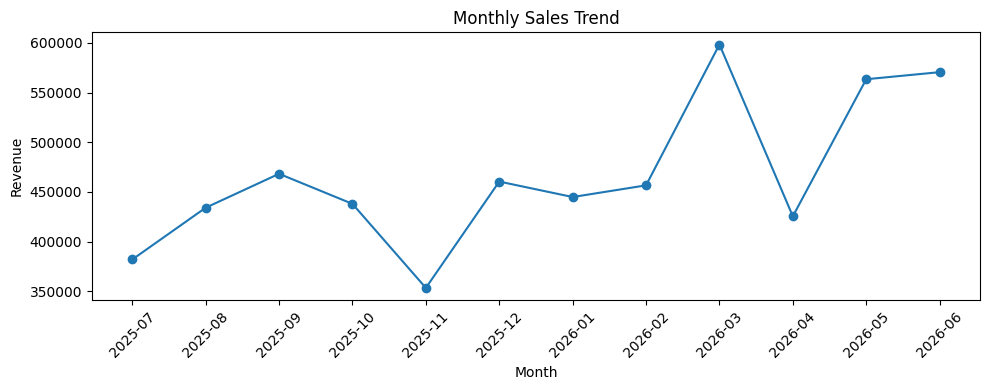

In [5]:
# Quick visualization of the monthly trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(monthly["month"], monthly["monthly_sales"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Business Question 3: Customer segmentation by spend

In [6]:
q3 = """
WITH customer_spend AS (
    SELECT o.customer_id, SUM(o.quantity * p.price) AS total_spend
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY o.customer_id
)
SELECT customer_id, total_spend,
       CASE
           WHEN total_spend >= 15000 THEN 'High'
           WHEN total_spend >= 7000  THEN 'Medium'
           ELSE 'Low'
       END AS segment
FROM customer_spend
ORDER BY total_spend DESC;
"""
segments = db.query(q3)
segments["segment"].value_counts()

segment
High    120
Name: count, dtype: int64

## Business Question 4: Revenue by region

In [7]:
q4 = """
SELECT c.region, ROUND(SUM(o.quantity * p.price), 2) AS revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products p ON o.product_id = p.product_id
GROUP BY c.region
ORDER BY revenue DESC;
"""
db.query(q4)

,region,revenue
0,South,1513211.0
1,North,1492355.0
2,East,1296019.0
3,West,1294729.0


## Business Question 5: Average order value (AOV) per customer

In [8]:
q5 = """
SELECT o.customer_id, ROUND(AVG(o.quantity * p.price), 2) AS avg_order_value
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY o.customer_id
ORDER BY avg_order_value DESC
LIMIT 10;
"""
db.query(q5)

,customer_id,avg_order_value
0,98,3684.45
1,118,3477.00
2,68,3290.80
3,26,3153.88
4,15,3152.91
5,29,3112.50
6,73,3052.31
7,16,3007.06
8,6,2965.08
9,56,2948.06


## Business Question 6: Repeat customers vs one-time customers

In [9]:
q6 = """
WITH order_counts AS (
    SELECT customer_id, COUNT(*) AS num_orders
    FROM orders
    GROUP BY customer_id
)
SELECT
    CASE WHEN num_orders > 1 THEN 'Repeat Customer' ELSE 'One-time Customer' END AS customer_type,
    COUNT(*) AS num_customers
FROM order_counts
GROUP BY customer_type;
"""
db.query(q6)

,customer_type,num_customers
0,Repeat Customer,120


## Business Question 7: Product category performance

In [10]:
q7 = """
SELECT p.category,
       SUM(o.quantity) AS units_sold,
       ROUND(SUM(o.quantity * p.price), 2) AS revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
"""
db.query(q7)

,category,units_sold,revenue
0,Electronics,952,2232248.0
1,Sports,786,1390614.0
2,Home & Kitchen,970,1089080.0
3,Apparel,597,633103.0
4,Books,631,251269.0


## Business Question 8: Month-over-month sales growth %

In [11]:
q8 = """
WITH monthly_revenue AS (
    SELECT strftime('%Y-%m', o.order_date) AS month,
           SUM(o.quantity * p.price) AS revenue
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY month
)
SELECT month, revenue,
       ROUND(
         (revenue - LAG(revenue) OVER (ORDER BY month)) * 100.0
         / NULLIF(LAG(revenue) OVER (ORDER BY month), 0), 2
       ) AS mom_growth_pct
FROM monthly_revenue
ORDER BY month;
"""
db.query(q8)

,month,revenue,mom_growth_pct
0,2025-07,382052.0,NaN
1,2025-08,434165.0,13.64
2,2025-09,468323.0,7.87
3,2025-10,438045.0,-6.47
4,2025-11,353454.0,-19.31
5,2025-12,460501.0,30.29
6,2026-01,444932.0,-3.38
7,2026-02,456688.0,2.64
8,2026-03,598466.0,31.04
9,2026-04,425550.0,-28.89


## Business Question 9: Top 10 customers ranked by total spend

In [12]:
q9 = """
WITH customer_spend AS (
    SELECT o.customer_id, c.customer_name, SUM(o.quantity * p.price) AS total_spend
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN products p ON o.product_id = p.product_id
    GROUP BY o.customer_id, c.customer_name
)
SELECT customer_name, total_spend,
       RANK() OVER (ORDER BY total_spend DESC) AS rank
FROM customer_spend
ORDER BY rank
LIMIT 10;
"""
db.query(q9)

,customer_name,total_spend,rank
0,Riya Reddy,90402.0,1
1,Manav Reddy,87150.0,2
2,Arjun Malhotra,81058.0,3
3,Neha Verma,76361.0,4
4,Sahil Gupta,73456.0,5
5,Karan Verma,72517.0,6
6,Kavya Verma,71500.0,7
7,Karan Malhotra,71162.0,8
8,Ishita Sharma,70508.0,9
9,Meera Kapoor,69401.0,10


## Business Question 10: Running total (cumulative) of monthly sales

In [13]:
q10 = """
WITH monthly_revenue AS (
    SELECT strftime('%Y-%m', o.order_date) AS month,
           SUM(o.quantity * p.price) AS revenue
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY month
)
SELECT month, revenue,
       SUM(revenue) OVER (ORDER BY month) AS running_total
FROM monthly_revenue
ORDER BY month;
"""
db.query(q10)

,month,revenue,running_total
0,2025-07,382052.0,382052.0
1,2025-08,434165.0,816217.0
2,2025-09,468323.0,1284540.0
3,2025-10,438045.0,1722585.0
4,2025-11,353454.0,2076039.0
5,2025-12,460501.0,2536540.0
6,2026-01,444932.0,2981472.0
7,2026-02,456688.0,3438160.0
8,2026-03,598466.0,4036626.0
9,2026-04,425550.0,4462176.0


## Wrap-up
All 10 business questions were answered directly from SQL, run through the reusable `Database` utility class in `db_utils.py`. This same pattern (SQLAlchemy engine + `pandas.read_sql`) can be reused for any future business question by simply writing new SQL and calling `db.query(sql)`.

In [14]:
db.close()